# Predicting EUR/USD 

### Descriptive analysis of your data


In [ ]:
# download csv file locally
import pandas as pd

data = pd.read_csv("Data_EURUSD_4h.csv")
data.info()
data.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28860 entries, 0 to 28859
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gmt time  28860 non-null  object 
 1   open      28860 non-null  float64
 2   high      28860 non-null  float64
 3   low       28860 non-null  float64
 4   close     28860 non-null  float64
 5   volume    28860 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.3+ MB


(28860, 6)

In [5]:
data.head()

,Gmt time,open,high,low,close,volume
0,04.05.2003 21:00:00.000,1.12354,1.12354,1.12166,1.12274,95533.0976
1,05.05.2003 01:00:00.000,1.12242,1.12276,1.12067,1.12126,93778.5996
2,05.05.2003 05:00:00.000,1.12139,1.12255,1.12030,1.12113,90924.6992
3,05.05.2003 09:00:00.000,1.12092,1.12331,1.12049,1.12174,91254.6992
4,05.05.2003 13:00:00.000,1.12194,1.12900,1.12130,1.12712,308003.4083


In [6]:
# show if there is any missing value
data.isnull().sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [7]:
# show if a value is zero
(data == 0).sum()

Gmt time     0
open         0
high         0
low          0
close        0
volume      34
dtype: int64

In [9]:
data[data['volume'] == 0]

,Gmt time,open,high,low,close,volume
120,31.05.2003 21:00:00.000,1.17691,1.17825,1.17691,1.17825,0.0
1561,30.04.2004 21:00:00.000,1.19800,1.19853,1.19800,1.19853,0.0
1952,31.07.2004 21:00:00.000,1.20195,1.20195,1.20161,1.20161,0.0
3123,30.04.2005 21:00:00.000,1.28715,1.28722,1.28715,1.28722,0.0
3784,30.09.2005 21:00:00.000,1.20266,1.20664,1.20266,1.20664,0.0
4175,31.12.2005 22:00:00.000,1.18465,1.18470,1.18465,1.18470,0.0
4566,31.03.2006 22:00:00.000,1.21158,1.21158,1.21144,1.21144,0.0
4957,30.06.2006 21:00:00.000,1.27925,1.27925,1.27865,1.27865,0.0
5348,30.09.2006 21:00:00.000,1.26735,1.26735,1.26704,1.26704,0.0
6129,31.03.2007 21:00:00.000,1.33560,1.33560,1.33545,1.33545,0.0


In [29]:
# drop column Gmt time
data = data.drop(columns=['Gmt time'])

In [30]:
mean_volume = data['volume'].mean()

print("Mean volume (excluding zeros):", mean_volume)

Mean volume (excluding zeros): 83078.83538814967


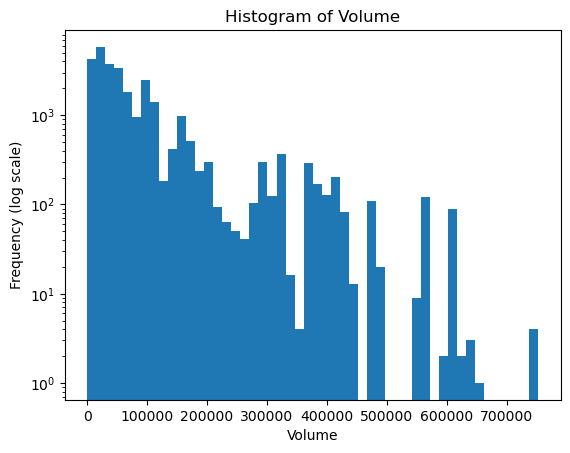

In [31]:
# histogram of volume
import matplotlib.pyplot as plt
plt.hist(data['volume'], bins=50)
plt.yscale('log')
plt.xlabel('Volume')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Volume')
plt.show()

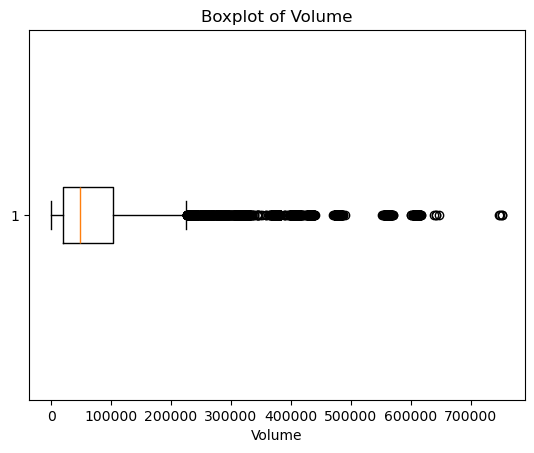

In [32]:
# boxplot of volume
plt.boxplot(data['volume'], vert=False)
plt.xlabel('Volume')
plt.title('Boxplot of Volume')
plt.show()


with the different plot, we can concluded that 0 is not an aberrant value. 

In [33]:
data.describe()

,open,high,low,close,volume
count,28860.000000,28860.000000,28860.000000,28860.000000,28860.000000
mean,1.254449,1.256497,1.252384,1.254457,83078.835388
std,0.119505,0.119839,0.119131,0.119503,100637.239637
min,1.036930,1.039200,1.034050,1.036970,0.000000
25%,1.154278,1.155988,1.152438,1.154285,20322.189925
50%,1.242230,1.244390,1.239885,1.242260,47812.714850
75%,1.338760,1.340750,1.336512,1.338763,102454.949700
max,1.599500,1.604030,1.596950,1.599240,752269.093800


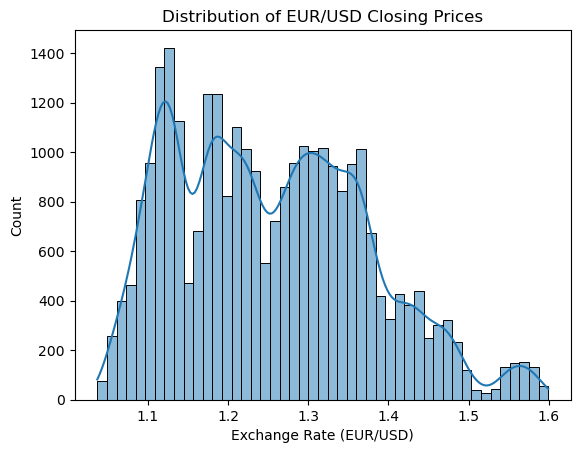

In [34]:
# Distributions between Euro and Dollar exchange rates
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(data['close'], kde=True)
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Exchange Rate (EUR/USD)")
plt.show()

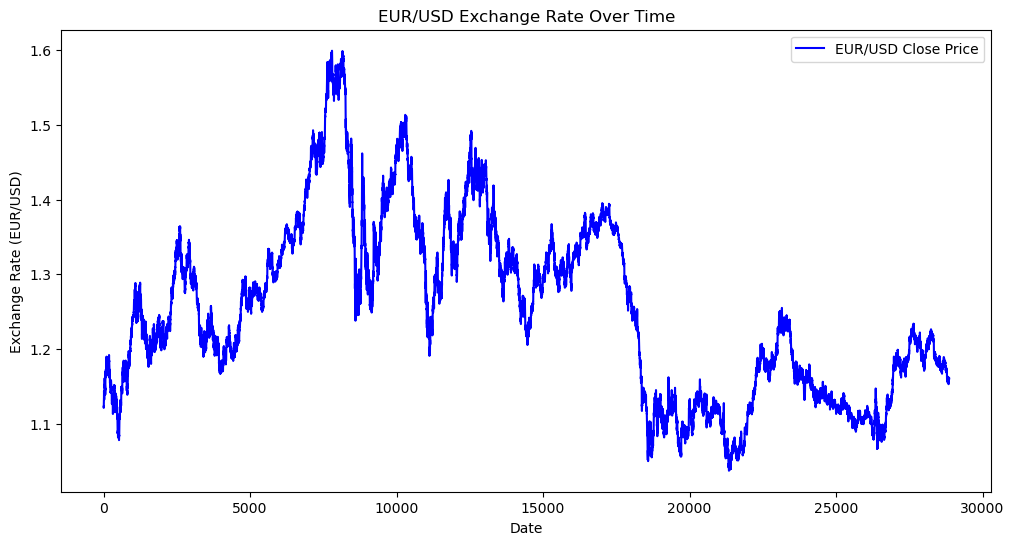

In [35]:
# affichage du cours de clôture au fil du temps
plt.figure(figsize=(12,6))
plt.plot(data.index, data['close'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

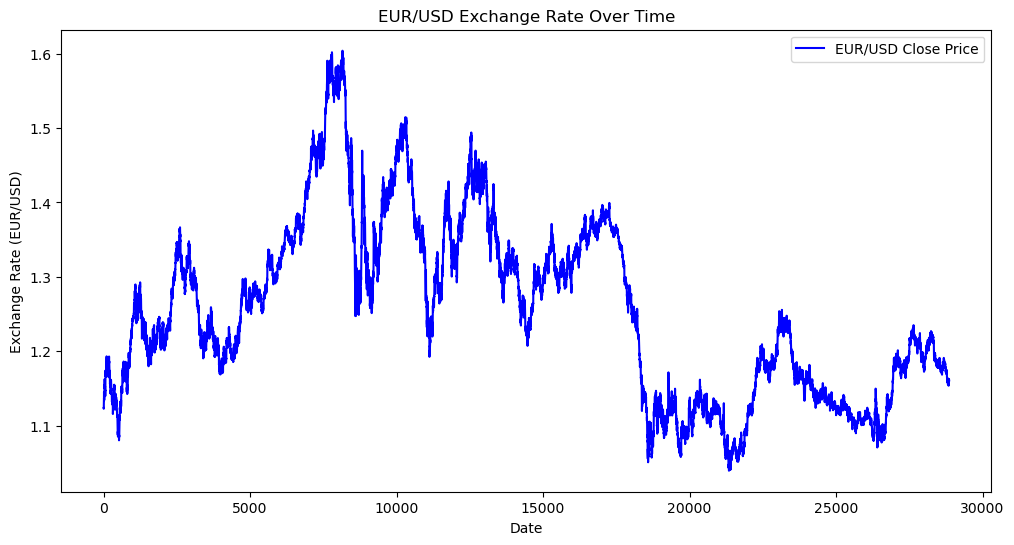

In [36]:
# affichage du cours de clôture au fil du temps
plt.figure(figsize=(12,6))
plt.plot(data.index, data['high'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

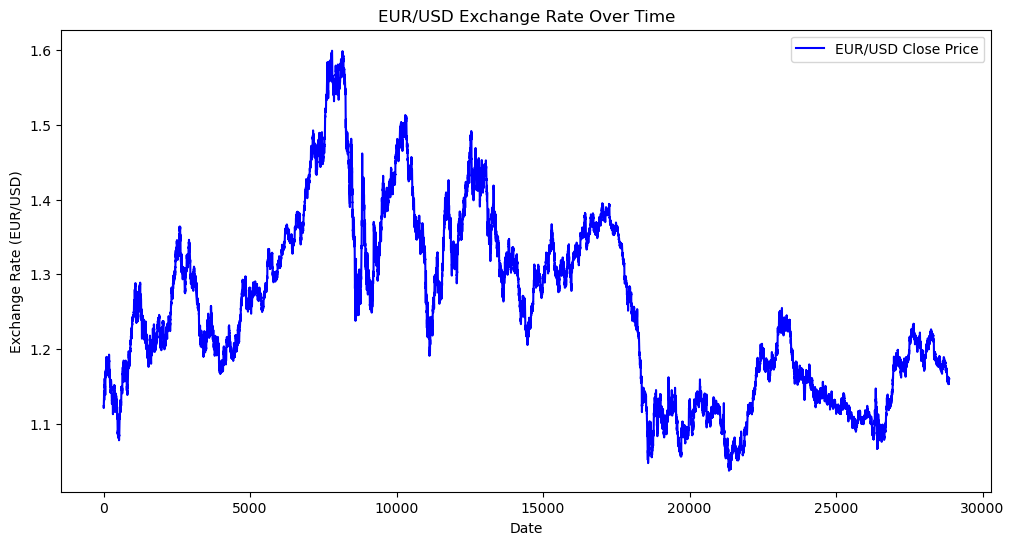

In [37]:
# affichage du cours de clôture au fil du temps
plt.figure(figsize=(12,6))
plt.plot(data.index, data['open'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

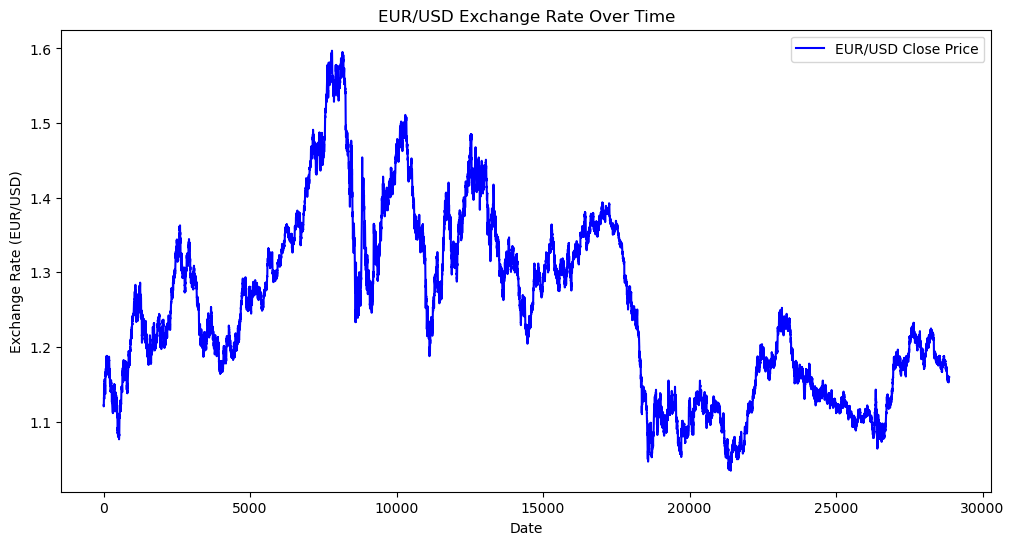

In [38]:
# show the plot of exchange rate over time
plt.figure(figsize=(12,6))
plt.plot(data.index, data['low'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

### Conclusion : Descriptive analysis of your data.
Our dataset contains historical exchange rates between Euro and US Dollar.
this dataset contains 28860 records with 6 features: Gmt time, Open, High, Low, Close, and Volume.
Remainder that the FX euro dollar is open 24 hours a day from Monday to Friday, so the data is recorded for every trading day. And without holidays.
we have seen that there are no missing values and the zero values are not problematic.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

df = data.copy()

# add some indicators that we know without volume data
df['Return'] = df['close'].pct_change()
df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()
df['Volatility'] = df['Return'].rolling(10).std()
df['RSI'] = 100 - (100 / (1 + df['Return'].rolling(14).apply(lambda x: (x[x > 0].sum() / -x[x < 0].sum()) if -x[x < 0].sum() != 0 else 0)))
df["EMA12"] = df['close'].ewm(span=12, adjust=False).mean()
df["EMA26"] = df['close'].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]
df["VMA5"] = df['volume'].rolling(5).mean()
df["VMA20"] = df['volume'].rolling(20).mean()
df["Volume_Ratio"] = df["VMA5"] / df["VMA20"]

# Add lagged values to keep memory of the past
for lag in range(1, 6):  # 5 days of lag
    df[f'Lag_{lag}'] = df['close'].shift(lag)
    
# Delete missing values
df = df.dropna()

print("\nIndicator created :")
print(df.head())

# We choose to predict the market direction (1 = up, 0 = down)
df['Target'] = (df['Return'].shift(-1) > 0).astype(int)
df = df.dropna()

X = df.drop(columns=['Target', 'Return', 'open', 'high', 'low']) 
y = df['Target']

# split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Different classification models to test
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": SVC(kernel='rbf', C=1.0, probability=True)
}

results = {}

print("\nModel evaluation :")
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    results[name] = [acc, prec, rec, f1, auc]
    print(f"{name:20s} , Acc: {acc:.3f} , Prec: {prec:.3f} , Rec: {rec:.3f} , F1: {f1:.3f} , AUC: {auc:.3f}")

# Results 
results_df = pd.DataFrame(results, index=["Accuracy", "Precision", "Recall", "F1", "AUC"]).T
print("\nResume of performance :")
print(results_df)

# best model
best_model_name = results_df["AUC"].idxmax()
print(f"\nBest model based on AUC: {best_model_name}")


Indicator created :
       open     high      low    close       volume    Return       MA5  \
19  1.13529  1.13623  1.13169  1.13210   98309.7012 -0.003495  1.136078   
20  1.13155  1.13412  1.13026  1.13312   89533.6016  0.000901  1.134374   
21  1.13341  1.14342  1.13236  1.14334   91527.1992  0.009019  1.136280   
22  1.14336  1.14855  1.14240  1.14540  313726.1035  0.001802  1.138006   
23  1.14547  1.15092  1.14514  1.15026  373156.8946  0.004243  1.140844   

        MA20  Volatility        RSI  ...     EMA26      MACD          VMA5  \
19  1.132595    0.003787  55.531832  ...  1.132100  0.003283  193500.21878   
20  1.133114    0.003797  55.444104  ...  1.132176  0.002860  193497.19886   
21  1.134218    0.004149  65.787992  ...  1.133003  0.003310  149653.09962   
22  1.135431    0.004176  63.263365  ...  1.133921  0.003790  137150.36094   
23  1.136858    0.004341  66.371954  ...  1.135131  0.004510  193250.70002   

            VMA20  Volume_Ratio    Lag_1    Lag_2    Lag_3 

we notice that basic modele isn't suited for time series we'll implement more complex models later like ARIMA, XGBoost that are specifically built to forecast time series datasets.